In [1]:
using PowerDynamics
using PowerDynamics: Library
using PowerDynamics.Library.ComposableInverter: SimpleGFLDC
using OrdinaryDiffEqRosenbrock
using OrdinaryDiffEqNonlinearSolve
using CairoMakie
using Graphs
using GraphPlot
using ModelingToolkit
using Accessors
using AccessorsExtra
using SparseArrays
using Symbolics
using LinearSolve
using DifferentialEquations
using JSON3
using Colors
using Plots
using Serialization

In [2]:
data = JSON3.read(read("names.json", String))
sol2 = deserialize("sims/shutdown.jld2")
println("finished")

finished


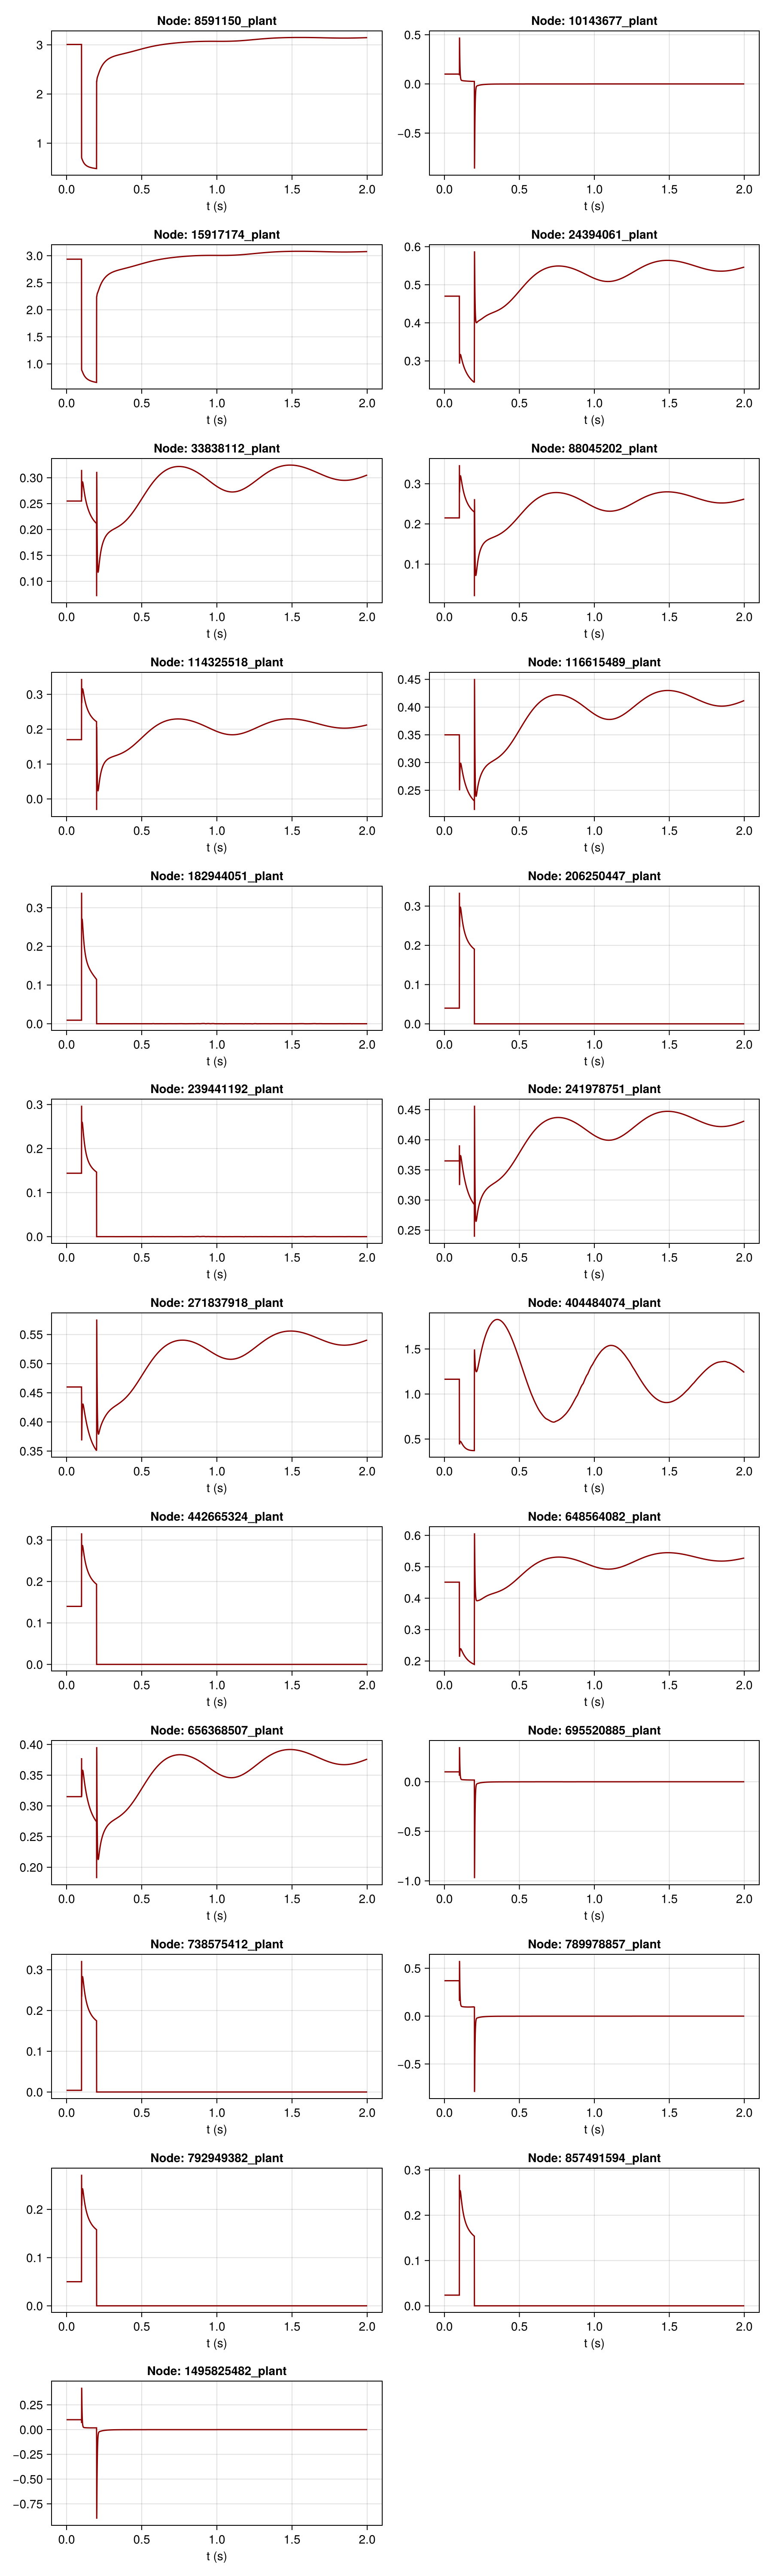

In [3]:
#plants
let
    fig = Figure(size = (900, 10 * 300))
    cols = 2

    i = 1
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2 || parts[2] != "plant"
            continue
        end
        
        row = (i - 1) ÷ cols + 1
        col = (i - 1) % cols + 1
        
        ax = Axis(fig[row, col], title="Node: $(name)", xlabel="t (s)", ylabel="")
        
        lines!(ax, sol2, idxs=VIndex(Symbol(name), :busbar₊P), color=:darkred)
        

        i += 1
    end
    
    fig
end

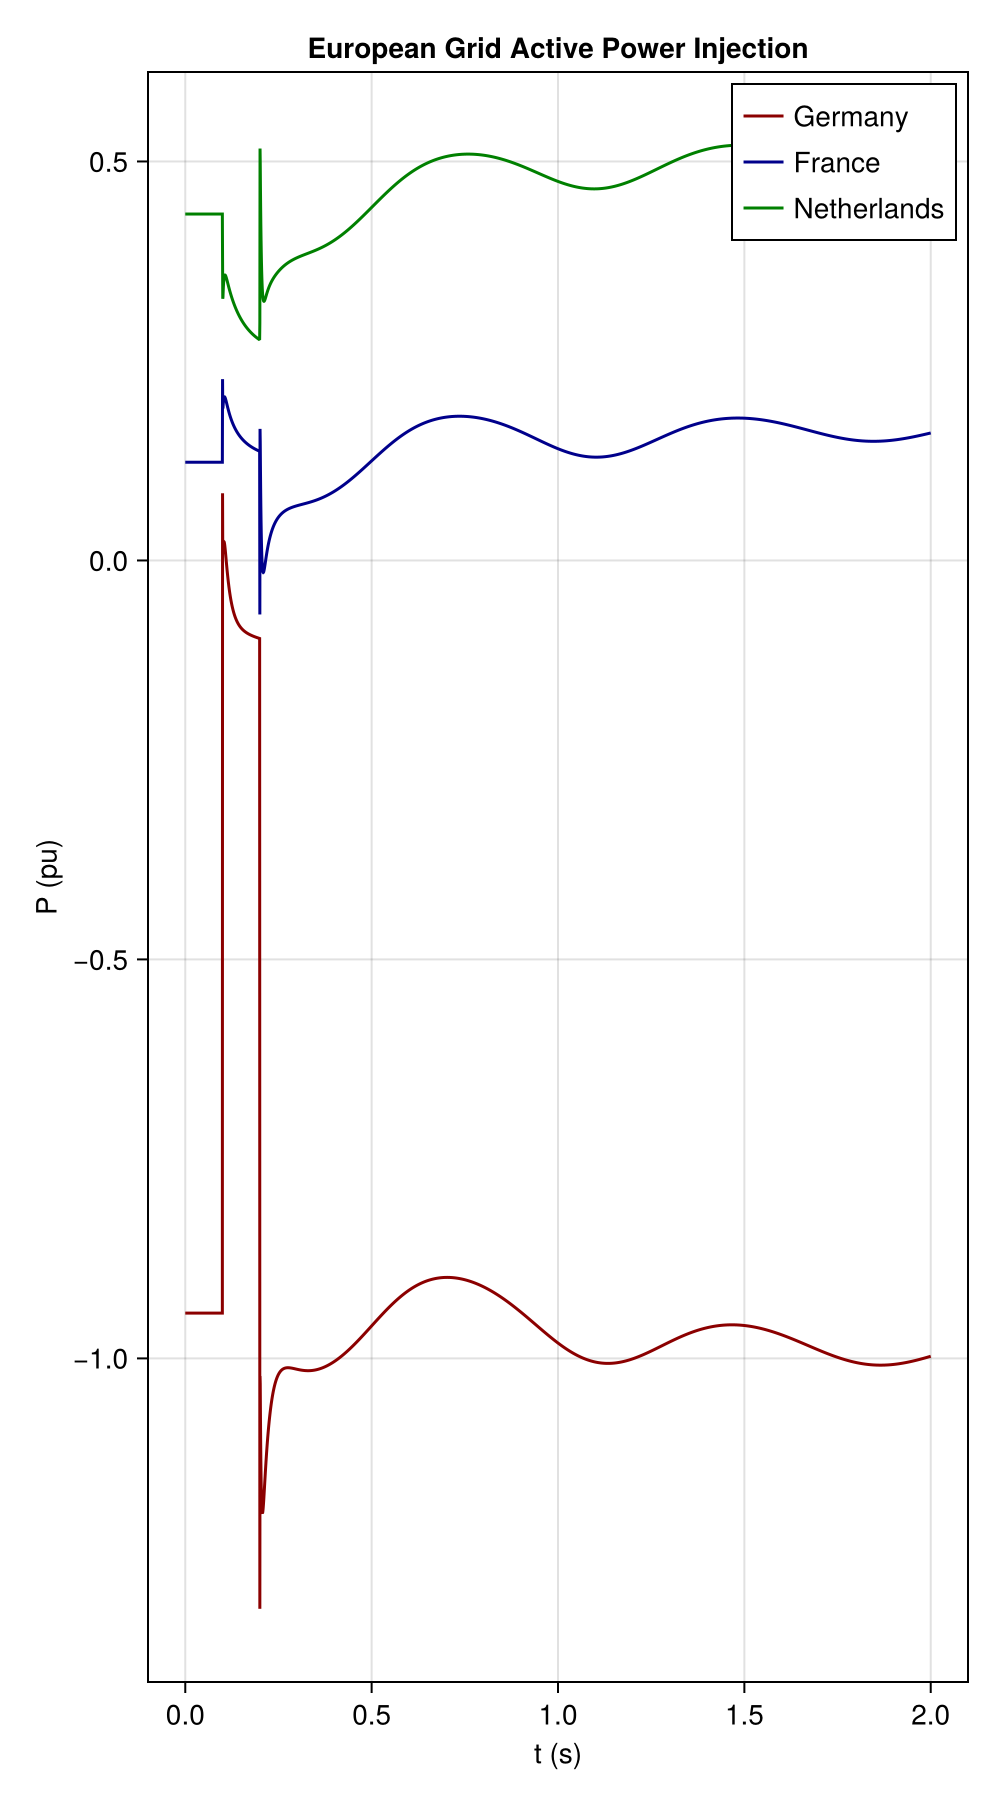

In [4]:
#slack
let
    fig = Figure()
    fig = Figure(size = (500, 3 * 300))
    cols = 2
    
    ax = Axis(fig[1, 1], title="European Grid Active Power Injection", xlabel="t (s)", ylabel="P (pu)")
    
    lines!(ax, sol2, idxs=VIndex(:Germany, :busbar₊P), color=:darkred, label="Germany")
    lines!(ax, sol2, idxs=VIndex(:France, :busbar₊P), color=:darkblue, label="France")
    lines!(ax, sol2, idxs=VIndex(:Netherlands, :busbar₊P), color=:green, label="Netherlands")
    
    axislegend(ax, position=:rt)
    fig
end